# **Pytroch workflow from Scratch**
**Workflow :** A workflow is a repeatable set of steps used to build,train, evalute and save any machine learning model.

Every model has these 6 steps.
1. Data (prepare and load)
2. Build model
3. Train the model (fit to data)
4. Infernce (predict and evalution)
5. Save and load model
6. Put it all together

# Step by step Impletation

## Step 1: Import pytorch

In [2]:
import torch
from torch import nn
import matplotlib.pyplot as plt
print("Done")

Done


## Step 2: Data (Prepare & Load)

In [3]:
weights=0.7
bias=0.3

start=0
end=1
step=0.02

X=torch.arange(start,end,step).unsqueeze(dim=1)
y=weights*X+bias

print(X.shape)
print(X[:10])
print(y[:10])

torch.Size([50, 1])
tensor([[0.0000],
        [0.0200],
        [0.0400],
        [0.0600],
        [0.0800],
        [0.1000],
        [0.1200],
        [0.1400],
        [0.1600],
        [0.1800]])
tensor([[0.3000],
        [0.3140],
        [0.3280],
        [0.3420],
        [0.3560],
        [0.3700],
        [0.3840],
        [0.3980],
        [0.4120],
        [0.4260]])


### Step 2.1: Train - Test - Split.

In [4]:
train_split=int(0.8*len(X))
x_train=X[:train_split]
x_test=X[train_split:]
y_train=y[:train_split]
y_test=y[train_split:]
print(x_train.shape)
print(x_test.shape)

torch.Size([40, 1])
torch.Size([10, 1])


### Step 2.2: Visualisation

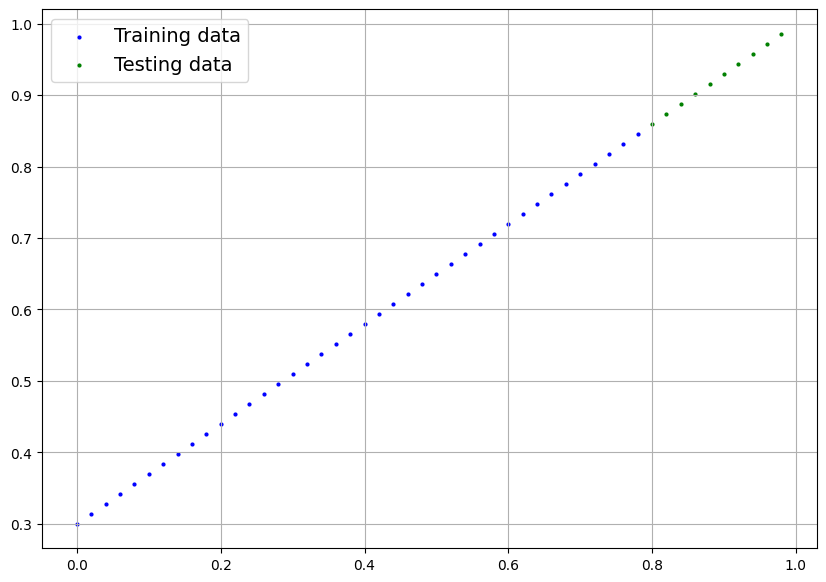

In [21]:
def plot_predictions(train_data, train_labels, test_data, test_labels, predictions=None):
    plt.figure(figsize=(10, 7))
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")
    if predictions is not None:
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")
    plt.legend(prop={"size": 14})
    plt.grid(True)
plot_predictions(x_train, y_train, x_test, y_test)

### Step 2.3: Build the model

In [6]:
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1), requires_grad=True)
        self.bias    = nn.Parameter(torch.randn(1), requires_grad=True)

    def forward(self, x):
        return self.weights * x + self.bias

### Step 2.4: Inspect The model 

In [7]:
torch.manual_seed(42)
model_0 = LinearRegressionModel()

list(model_0.parameters())
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

### Step 2.5: Make the predictions(Untrained)

In [8]:
with torch.inference_mode():
    y_preds=model_0(x_test)

### Step 2.6: Visualise the Bad preduictions

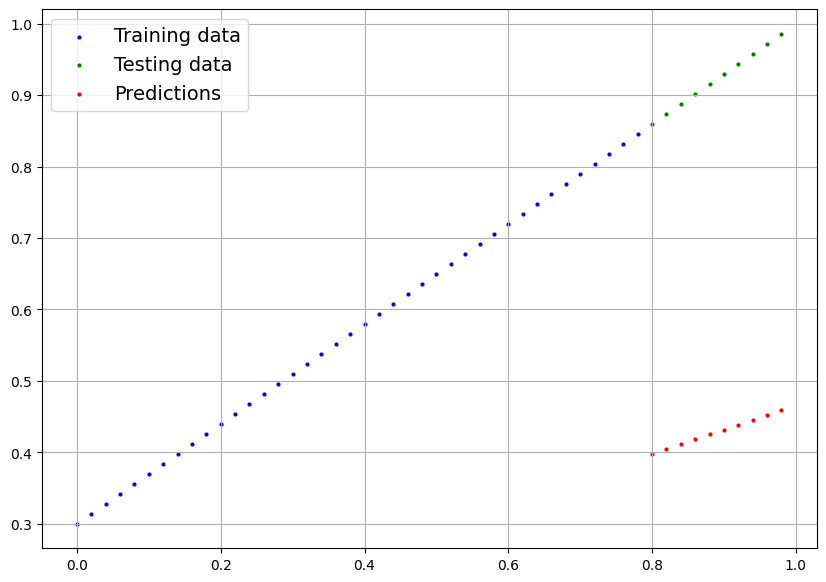

In [22]:
plot_predictions(x_train, y_train, x_test, y_test, predictions=y_preds)

## Step 3: Train The Model
### Step 3.1:Loss function and optimizer

In [25]:
loss_fn=nn.L1Loss()
optimizer=torch.optim.SGD(params=model_0.parameters(),lr=0.01)
print("Done")


Done


### Step 3.2: TRaining Loop

In [26]:
torch.manual_seed(42)
epochs=100

train_loss_values=[]
test_loss_values=[]
epoch_count=[]

for epoch in range(epochs):
    model_0.train()

    y_pred=model_0(x_train)
    loss=loss_fn(y_pred,y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_0.eval()
    with torch.inference_mode():
        test_pred=model_0(x_test)
        test_loss=loss_fn(test_pred,y_test)
    if epoch % 10 ==0:
        epoch_count.append(epoch)
        train_loss_values.append(loss.detach().numpy())
        test_loss_values.append(test_loss.detach().numpy())
        print(f"Epoch {epoch} Train loss{loss} and Test Loss {test_loss}")


Epoch 0 Train loss0.31288138031959534 and Test Loss 0.48106518387794495
Epoch 10 Train loss0.1976713240146637 and Test Loss 0.3463551998138428
Epoch 20 Train loss0.08908725529909134 and Test Loss 0.21729660034179688
Epoch 30 Train loss0.053148526698350906 and Test Loss 0.14464017748832703
Epoch 40 Train loss0.04543796554207802 and Test Loss 0.11360953003168106
Epoch 50 Train loss0.04167863354086876 and Test Loss 0.09919948130846024
Epoch 60 Train loss0.03818932920694351 and Test Loss 0.08886633068323135
Epoch 70 Train loss0.03476089984178543 and Test Loss 0.0805937647819519
Epoch 80 Train loss0.03132382780313492 and Test Loss 0.07232122868299484
Epoch 90 Train loss0.02788739837706089 and Test Loss 0.06473556160926819


### Step 3.3 : Plot Loss Curves

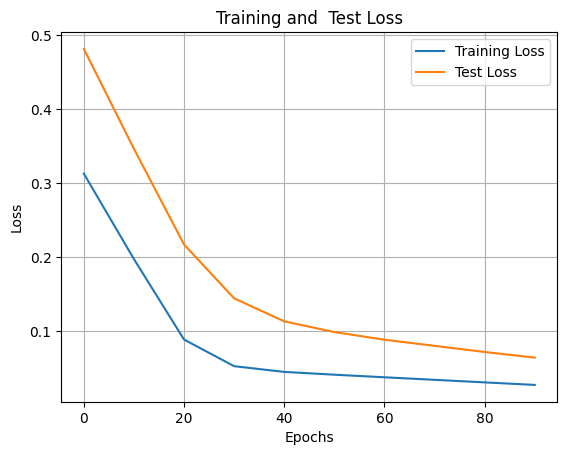

In [27]:
plt.plot(epoch_count,train_loss_values,label="Training Loss")
plt.plot(epoch_count,test_loss_values,label="Test Loss")
plt.title("Training and  Test Loss")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()
plt.grid(True)


### Step 3.4: Check what model learned

In [28]:
print(model_0.state_dict())
print(f"Orginal Weight {weights} and bias {bias}")

OrderedDict({'weights': tensor([0.5784]), 'bias': tensor([0.3513])})
Orginal Weight 0.7 and bias 0.3
